# 07 — Avaliação, sampling e entropia do corpus

> Escopo: interpretar a cross-entropy, sampling, geração e o estudo de entropia
> do corpus (resultados do projeto).
> Fecha a série: aqui medimos *quão bom* o modelo é, *como* geramos texto dele,
> e qual fator de fato limita um modelo pequeno.

Treinar é metade; a outra metade é saber **ler o número**. Uma cross-entropy de
1,586 é boa ou ruim? O que ela diz em bits? Como transformo logits em texto sem que
o modelo entre em loop? E — a pergunta que ordena todo o roadmap — o que limita um
modelo pequeno: a complexidade do texto ou a quantidade dele?

**O que você vai sair sabendo:**
1. Interpretar cross-entropy: o piso `log(V)`, informação ganha por token, e BPC
   (bits per character) — a única métrica comparável entre tokenizers diferentes.
2. Implementar `evaluate` (loss + next-token accuracy) e por que acurácia satura antes da loss.
3. Implementar `sample_next` com temperatura, top-k, top-p e repetition penalty,
   e *ver* cada botão remodelar a distribuição.
4. Um loop `generate` autoregressivo mínimo.
5. Por que, com 1,8M parâmetros, **a entropia do corpus domina o volume de dados**
   — medido por ablação, não afirmado.

Este notebook alimenta os stubs `src/tucanoce/training/evaluate.py` e
`src/tucanoce/inference/generate.py`.

In [1]:
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(0)
np.random.seed(0)
print("torch", torch.__version__)

torch 2.12.1+cpu


## 1. Interpretando a cross-entropy (nb 07)

O objetivo de treino é a cross-entropy autoregressiva (nb 06). Mas o valor cru
— digamos $\mathcal{L}_{val} = 2{,}27$ nats/token — não significa nada isolado.
Precisamos de referências.

**O piso trivial.** Um modelo que não aprendeu nada chuta uniforme sobre o
vocabulário: probabilidade $1/V$ para cada token. A cross-entropy disso é

$$ \mathcal{L}_{\text{trivial}} = -\log\tfrac{1}{V} = \log V. $$

Com $V = 4096$, isso é $\log 4096 \approx 8{,}32$ nats. Qualquer modelo útil fica
**abaixo** desse piso. Nosso preset *small* treinado no TinyStories atinge
$\mathcal{L}_{val} = 1{,}586$, e a diferença mede **informação ganha por token**:

$$ \mathcal{L}_{val} - \log V = 1{,}586 - 8{,}318 = -6{,}732 \text{ nats/token}. $$

Convertendo para bits (dividir por $\ln 2$): o modelo elimina $\approx 9{,}7$ bits
de incerteza por token em relação ao chute cego.

Mas o piso trivial é uma régua frouxa — bater "chute uniforme" é fácil. Uma régua
honesta é $H_2$, a entropia condicional de bigrama do corpus (o que um contador de
pares acertaria): 2,995 nats no TinyStories. É contra ela que mediremos o modelo.

In [2]:
V = 4096
L_val = 1.586   # small (1,8M) no TinyStories

floor_nats = math.log(V)
info_gain_nats = L_val - floor_nats          # negativo: reduzimos a incerteza
info_gain_bits = -info_gain_nats / math.log(2)

print(f"piso trivial log(V)      = {floor_nats:.4f} nats")
print(f"L_val                    = {L_val:.4f} nats")
print(f"informação ganha         = {info_gain_bits:.2f} bits/token")
assert floor_nats > L_val, "um modelo útil fica abaixo do piso"

piso trivial log(V)      = 8.3178 nats
L_val                    = 1.5860 nats
informação ganha         = 9.71 bits/token


**Bits per character (BPC).** A cross-entropy crua depende do tokenizer: mudar o
vocabulário muda a escala e a comparação deixa de ser justa. A métrica portável é
**bits por caractere** : quantos bits o modelo gasta, em média, por
*byte* do texto original — independente de como o texto foi fatiado em tokens.

$$ \text{BPC} = \frac{\mathcal{L}_{val}}{\text{bytes\_por\_token}\cdot \ln 2}. $$

No TinyStories cada token comprime em média $2{,}29$ bytes (medido por
`scripts/entropia_corpora.py`, ver nb 02), então:

In [3]:
def bits_per_char(val_loss_nats: float, bytes_per_token: float) -> float:
    '''Cross-entropy (nats/token) -> bits por caractere. Portável entre tokenizers.'''
    return val_loss_nats / (bytes_per_token * math.log(2))

bpc = bits_per_char(L_val, bytes_per_token=2.29)
print(f"BPC do TucanoCE small (in-corpus) = {bpc:.3f} bits/byte")
print(f"BPB no held-out (benchmark.py)    = 1.013 bits/byte")
print(f"BPB do GPT-2 124M, zero-shot      = 0.772 bits/byte")
assert abs(bpc - 1.00) < 0.02

BPC do TucanoCE small (in-corpus) = 0.999 bits/byte
BPB no held-out (benchmark.py)    = 1.013 bits/byte
BPB do GPT-2 124M, zero-shot      = 0.772 bits/byte


Sobre 150 histórias *held-out*, o `benchmark.py` mede **BPB 1,013** para o nosso
*small* contra **0,772** do GPT-2 (124M, *zero-shot*). O GPT-2 comprime melhor — e
boa parte disso é estrutural, não mérito de dados: ele tem contexto 8× maior (1024
contra 128) e vocabulário de 50.257 tokens, que fragmenta menos o texto.

O ponto que importa: BPB mede **compressão, não adequação à tarefa**. Pedido a gerar
uma história, o GPT-2 ignora o gênero e entra em laço; o nosso *small* de 1,8M produz
narrativa no estilo correto. "Menor BPB" não é "melhor na tarefa que interessa".

## 2. Next-token accuracy — e por que ela é enganosa sozinha

`evaluate` calcula duas coisas sobre o conjunto de validação:
- **val_loss**: a cross-entropy média (o que o early stopping monitora, nb 06).
- **accuracy**: fração de posições em que o token de maior logit é o correto.

Acurácia é uma métrica *dura* (acertou/errou), menos suave que a loss. Ela satura
antes: no nosso treino no TinyStories ela estaciona em ~66% enquanto a loss ainda
melhora — o modelo fica mais *calibrado* (dá mais probabilidade ao token certo) sem
necessariamente mudar qual é o argmax. Por isso a loss, e não a acurácia, guia as
decisões de treino.

Vamos montar um modelo e uma tarefa de brinquedo para exercitar a mecânica.

In [4]:
# --- Modelo de brinquedo: um mini-LM causal (1 bloco), só para exercitar avaliação/geração.
# Foco é a MECÂNICA, não qualidade de texto. Arquitetura completa vive nos nb 03/04.
class TinyLM(nn.Module):
    def __init__(self, vocab, d=32, n_heads=2, context=8):
        super().__init__()
        self.context = context
        self.n_heads = n_heads
        self.tok = nn.Embedding(vocab, d)
        self.pos = nn.Embedding(context, d)      # pos-emb aprendida (estilo GPT-2, nb 03)
        self.ln1 = nn.LayerNorm(d); self.ln2 = nn.LayerNorm(d)
        self.qkv = nn.Linear(d, 3 * d, bias=False)
        self.out = nn.Linear(d, d, bias=False)
        self.mlp = nn.Sequential(nn.Linear(d, 4 * d), nn.GELU(), nn.Linear(4 * d, d))
        self.lnf = nn.LayerNorm(d)
        self.head = nn.Linear(d, vocab, bias=False)
        self.head.weight = self.tok.weight       # weight tying (nb 03)

    def forward(self, idx):
        B, T = idx.shape
        h = self.tok(idx) + self.pos(torch.arange(T, device=idx.device))
        # atenção causal multi-head via scaled_dot_product_attention (nb 01/03)
        q, k, v = self.qkv(self.ln1(h)).chunk(3, dim=-1)
        q, k, v = (t.view(B, T, self.n_heads, -1).transpose(1, 2) for t in (q, k, v))
        a = F.scaled_dot_product_attention(q, k, v, is_causal=True)
        a = a.transpose(1, 2).reshape(B, T, -1)
        h = h + self.out(a)
        h = h + self.mlp(self.ln2(h))
        return self.head(self.lnf(h))            # logits (B, T, vocab)

VOCAB, CTX = 16, 8
model = TinyLM(VOCAB, context=CTX)
print("params:", sum(p.numel() for p in model.parameters()) - model.head.weight.numel())

params: 12896


In [5]:
# Tarefa de brinquedo: prever o próximo = (token + 1) % VOCAB. Aprendível e verificável.
def make_batch(bs=64):
    x = torch.randint(0, VOCAB, (bs, CTX))
    y = (x + 1) % VOCAB
    return x, y

opt = torch.optim.AdamW(model.parameters(), lr=3e-3)
model.train()
for step in range(400):
    x, y = make_batch()
    logits = model(x)
    loss = F.cross_entropy(logits.reshape(-1, VOCAB), y.reshape(-1))
    opt.zero_grad(); loss.backward(); opt.step()
print(f"loss final de treino: {loss.item():.4f}  (piso trivial log(V)={math.log(VOCAB):.4f})")

loss final de treino: 0.0006  (piso trivial log(V)=2.7726)


In [6]:
@torch.no_grad()
def evaluate(model, batches):
    '''Retorna val_loss (nats/token) e next-token accuracy sobre uma lista de (x,y).'''
    model.eval()
    tot_loss, tot_correct, tot_tokens = 0.0, 0, 0
    for x, y in batches:
        logits = model(x)
        loss = F.cross_entropy(logits.reshape(-1, VOCAB), y.reshape(-1), reduction="sum")
        tot_loss += loss.item()
        tot_correct += (logits.argmax(-1) == y).sum().item()
        tot_tokens += y.numel()
    return {"val_loss": tot_loss / tot_tokens, "acc": tot_correct / tot_tokens}

val_batches = [make_batch(128) for _ in range(5)]
metrics = evaluate(model, val_batches)
print(f"val_loss = {metrics['val_loss']:.4f} nats/token")
print(f"accuracy = {metrics['acc']:.1%}")
print(f"bits ganhos vs piso = {(math.log(VOCAB) - metrics['val_loss'])/math.log(2):.2f} bits/token")

val_loss = 0.0006 nats/token
accuracy = 100.0%
bits ganhos vs piso = 4.00 bits/token


O modelo aprendeu a regra: loss bem abaixo do piso e acurácia alta. Numa tarefa
real de linguagem, a acurácia satura antes da loss — mas a mecânica de medir é
exatamente esta. É o que vai no stub `evaluate.py`.

### Lendo uma curva de treino real: onde o *early stopping* morde

A célula abaixo carrega a curva de um treino de verdade deste projeto — a ablação de
entropia/volume (`scripts/ablacao_entropia_volume.py`), preset *small* sobre 415.878
tokens do TinyStories. É a curva que o *early stopping* (nb 06) existe para ler: a
`val_loss` cai, achata, e em algum ponto para de melhorar. O `patience` conta
*epochs* sem melhora a partir daí; o checkpoint salvo é o do **melhor** `val_loss`,
não o do último *epoch*.

Se o JSON de resultados não existir, rode o script antes — não há número
*hardcoded* aqui de propósito: a figura tem que sair do experimento.

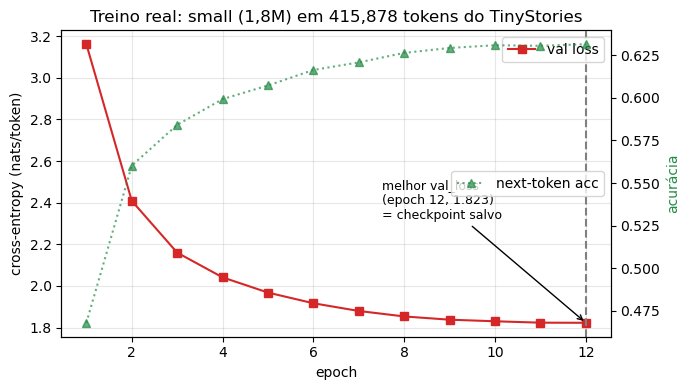

val loss: 3.161 -> mínimo 1.823 no epoch 12
acurácia: 0.468 -> 0.632
amostra gerada: Once upon a time, there was a little girl named Lily. She loved to play outside and explore the sky! One day, ...


In [7]:
import json, os
import matplotlib.pyplot as plt

RES = "../results/ablacao_entropia_volume.json"   # relativo a notebooks/
if not os.path.exists(RES):
    RES = "results/ablacao_entropia_volume.json"

if not os.path.exists(RES):
    print(f"sem {RES} — rode: python scripts/ablacao_entropia_volume.py")
else:
    r = json.load(open(RES, encoding="utf-8"))
    hist = r["history"]
    epochs = [h["epoch"] for h in hist]
    val    = [h["val_loss"] for h in hist]
    acc    = [h["acc"] for h in hist]
    best   = int(np.argmin(val))

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(epochs, val, "s-", color="#d62728", label="val loss")
    ax.axvline(epochs[best], ls="--", color="gray")
    ax.annotate(f"melhor val_loss\n(epoch {epochs[best]}, {val[best]:.3f})\n= checkpoint salvo",
                xy=(epochs[best], val[best]),
                xytext=(epochs[best] - 4.5, val[best] + 0.5),
                arrowprops=dict(arrowstyle="->"), fontsize=9)
    ax.set_xlabel("epoch"); ax.set_ylabel("cross-entropy (nats/token)")
    ax.set_title(f"Treino real: small (1,8M) em {r['n_tokens']:,} tokens do TinyStories")
    ax2 = ax.twinx()
    ax2.plot(epochs, acc, "^:", color="#238b45", alpha=0.7, label="next-token acc")
    ax2.set_ylabel("acurácia", color="#238b45")
    ax.legend(loc="upper right"); ax2.legend(loc="center right")
    ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

    print(f"val loss: {val[0]:.3f} -> mínimo {val[best]:.3f} no epoch {epochs[best]}")
    print(f"acurácia: {acc[0]:.3f} -> {acc[best]:.3f}")
    print(f"amostra gerada: {r['sample'][:110]}...")

## 3. Sampling: transformando logits em texto (nb 01)

Na geração, a última posição produz logits sobre o vocabulário. Como escolher o
próximo token? Amostrar da distribuição, mas com controle. Quatro botões:

- **Temperatura $	au$**: divide os logits antes do softmax.
  $\tau \to 0$ colapsa no *argmax* (texto previsível, repetitivo); $\tau$ alto
  achata a distribuição (mais variedade, risco de incoerência).
- **top-k**: mantém só os $k$ tokens mais prováveis, zera o resto. Corta a cauda.
- **top-p (nucleus)**: mantém o menor conjunto cuja probabilidade acumulada
  atinge $p$. Adaptativo — o tamanho do conjunto varia com a confiança do modelo.
- **repetition penalty**: penaliza tokens já emitidos, combatendo loops.

A ordem importa: penalidade de repetição → temperatura → top-k → top-p → softmax
→ amostragem.

In [8]:
def sample_next(logits, temperature=1.0, top_k=None, top_p=None,
                repetition_penalty=1.0, prev_tokens=None, generator=None):
    '''logits: (vocab,). Retorna id amostrado (int). Ordem: rep-penalty -> temp -> top-k -> top-p.'''
    logits = logits.clone().float()

    # repetition penalty (estilo CTRL): empurra tokens já vistos para baixo
    if repetition_penalty != 1.0 and prev_tokens is not None:
        for t in set(prev_tokens):
            logits[t] = logits[t] / repetition_penalty if logits[t] > 0 else logits[t] * repetition_penalty

    if temperature <= 0:                         # temperatura 0 = argmax determinístico
        return int(logits.argmax())
    logits = logits / temperature

    if top_k is not None:                        # zera tudo fora dos k maiores
        kth = torch.topk(logits, top_k).values[-1]
        logits[logits < kth] = float("-inf")

    if top_p is not None:                         # nucleus: menor conjunto com massa >= p
        s_logits, s_idx = torch.sort(logits, descending=True)
        cum = torch.softmax(s_logits, dim=-1).cumsum(dim=-1)
        remove = cum > top_p
        remove[..., 1:] = remove[..., :-1].clone()   # mantém sempre o 1º token
        remove[..., 0] = False
        logits[s_idx[remove]] = float("-inf")

    probs = torch.softmax(logits, dim=-1)
    return int(torch.multinomial(probs, 1, generator=generator))

In [9]:
# Demonstração: como cada botão remodela a MESMA distribuição de logits.
logits = torch.tensor([3.0, 2.5, 2.0, 0.5, 0.2, -1.0, -2.0, -3.0])
def show(name, probs):
    print(f"{name:22s} " + " ".join(f"{p:5.2f}" for p in probs))

show("logits (raw)", logits)
show("softmax tau=1.0", torch.softmax(logits, -1))
show("softmax tau=0.5", torch.softmax(logits / 0.5, -1))   # mais afiada
show("softmax tau=2.0", torch.softmax(logits / 2.0, -1))   # mais achatada

# top-k=3: só os 3 maiores sobrevivem
lk = logits.clone(); lk[lk < torch.topk(lk, 3).values[-1]] = float("-inf")
show("top-k=3", torch.softmax(lk, -1))

# top-p=0.7: menor núcleo com massa acumulada >= 0.7
s, idx = torch.sort(logits, descending=True)
cum = torch.softmax(s, -1).cumsum(-1); rem = cum > 0.7
rem[1:] = rem[:-1].clone(); rem[0] = False
lp = logits.clone(); lp[idx[rem]] = float("-inf")
show("top-p=0.7", torch.softmax(lp, -1))

logits (raw)            3.00  2.50  2.00  0.50  0.20 -1.00 -2.00 -3.00
softmax tau=1.0         0.47  0.28  0.17  0.04  0.03  0.01  0.00  0.00
softmax tau=0.5         0.66  0.24  0.09  0.00  0.00  0.00  0.00  0.00
softmax tau=2.0         0.31  0.24  0.19  0.09  0.08  0.04  0.03  0.02
top-k=3                 0.51  0.31  0.19  0.00  0.00  0.00  0.00  0.00
top-p=0.7               0.62  0.38  0.00  0.00  0.00  0.00  0.00  0.00


Leia as linhas: `tau=0.5` concentra massa no topo (mais determinístico);
`tau=2.0` espalha (mais aleatório); `top-k=3` e `top-p=0.7` zeram a cauda, cada um
por um critério diferente (contagem fixa vs. massa acumulada). Na prática o projeto
gerou com `temp=0.8, top-k=40` e usou `repetition_penalty=1.2` para escapar de
loops — combinar temperatura moderada com corte de cauda é o padrão.

As barras abaixo mostram os quatro botões agindo na **mesma** distribuição. Repare:
a temperatura redistribui a massa entre *todos* os tokens (nada zera); top-k e top-p
**zeram** parte da cauda (barras somem) — top-k por contagem fixa, top-p por massa
acumulada. As barras cinzas de fundo são a distribuição original, para comparação.

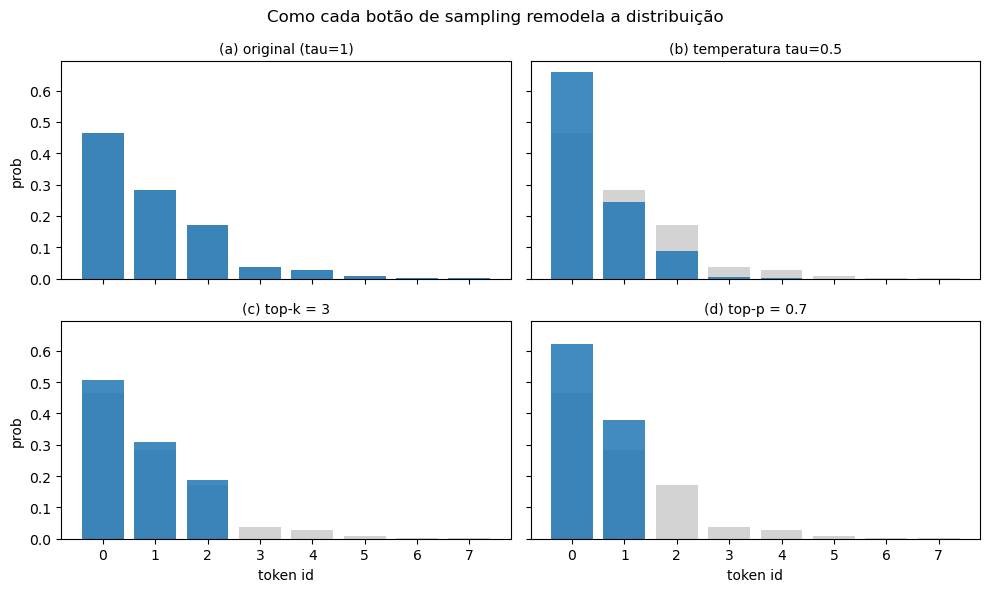

In [10]:
# Reaproveita logits, lk (top-k) e lp (top-p) já computados acima.
p_raw  = torch.softmax(logits, -1).numpy()
p_temp = torch.softmax(logits / 0.5, -1).numpy()
p_topk = torch.softmax(lk, -1).numpy()
p_topp = torch.softmax(lp, -1).numpy()
idxs = np.arange(len(logits))

fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True, sharey=True)
for ax, (title, p) in zip(axes.ravel(), [
        ("(a) original (tau=1)", p_raw), ("(b) temperatura tau=0.5", p_temp),
        ("(c) top-k = 3", p_topk), ("(d) top-p = 0.7", p_topp)]):
    ax.bar(idxs, p_raw, color="lightgray", label="original")  # sombra de referência
    ax.bar(idxs, p, color="C0", alpha=0.85)
    ax.set_title(title, fontsize=10)
axes[1, 0].set_xlabel("token id"); axes[1, 1].set_xlabel("token id")
axes[0, 0].set_ylabel("prob"); axes[1, 0].set_ylabel("prob")
fig.suptitle("Como cada botão de sampling remodela a distribuição")
plt.tight_layout(); plt.show()

## 4. Geração autoregressiva

O loop é simples: alimenta o contexto, pega os logits da **última** posição,
amostra o próximo token, concatena, repete. A versão abaixo recomputa o forward
inteiro a cada passo — custo $O(N^2)$ no comprimento gerado. O **nb 04** mostra a
versão com **KV-cache**, que reaproveita $K,V$ já calculados e derruba o custo
para $O(N)$; a mecânica de amostragem é idêntica.

In [11]:
@torch.no_grad()
def generate(model, prompt, max_new_tokens=12, temperature=0.8, top_k=8,
             top_p=None, repetition_penalty=1.2, generator=None):
    model.eval()
    ids = list(prompt)
    for _ in range(max_new_tokens):
        ctx = torch.tensor([ids[-model.context:]])       # janela de contexto
        logits = model(ctx)[0, -1]                        # logits da última posição
        nxt = sample_next(logits, temperature, top_k, top_p,
                          repetition_penalty, prev_tokens=ids, generator=generator)
        ids.append(nxt)
    return ids

g = torch.Generator().manual_seed(0)
out = generate(model, prompt=[5], max_new_tokens=10, generator=g)
print("prompt: [5]")
print("gerado:", out)
# o modelo brinquedo aprendeu 'próximo = (x+1)%V', então a continuação deve incrementar
print("regra aprendida (incrementar +1 mod 16):", out == [(5 + i) % VOCAB for i in range(len(out))])

prompt: [5]
gerado: [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
regra aprendida (incrementar +1 mod 16): True


O modelo brinquedo continua a sequência incrementando — exatamente a regra que
treinamos. É o esqueleto de `inference/generate.py`: contexto → logits → sample →
concatena. Trocar `TinyLM` pelo `TucanoCE` real (nb 03/04) e ligar o KV-cache é o
que falta para a inferência de produção.

## 5. O que limita um modelo pequeno: entropia do corpus ou volume de dados?

Duas leituras competem para explicar por que um modelo pequeno vai mal.

A primeira é de **escala**. Hoffmann et al. (2022, "Chinchilla") derivaram que o
ótimo de *compute* de um LM ocorre em

$$ T^* \approx 20 \cdot N, $$

com $T$ = tokens de treino e $N$ = parâmetros; $T/N \ll 20$ indica parâmetros
demais para os dados disponíveis. Cunha (2026), num setup irmão deste rodado em
GPU, reporta exatamente esse regime: sobre um corpus de 25,3M tokens de Wikipedia
técnica, um modelo de 43M (`L_val` 2,132) **supera** um de 211M, e dobrar
parâmetros com o corpus fixo não moveu o teto (2,266 → 2,278). Ou seja: naquele
regime, o gargalo era volume de dados.

A segunda leitura é de **entropia**. A cross-entropy se decompõe como

$$ \mathcal{L}(\theta) = H(p) + D_{\mathrm{KL}}(p \,\|\, q_\theta), $$

onde $H(p)$ é a entropia da distribuição do próprio corpus — **irredutível**, não
importa o modelo — e o termo KL é o que a capacidade pode fechar. Trocar o corpus
por um de $H(p)$ menor baixa o piso *e* encurta a distância que o modelo precisa
percorrer. Isso prevê algo que a leitura de escala não prevê: **com o volume de
dados fixo**, só mudar o domínio para texto mais simples deve derrubar a loss.

Os dois efeitos estavam confundidos no nosso estudo de corpora (o TinyStories tem
~7× mais tokens que o de física). A ablação em `scripts/ablacao_entropia_volume.py`
desacopla: TinyStories truncado ao **mesmo** número de tokens da física (415.878),
mesmo preset, mesmos hiperparâmetros.

In [12]:
import json, os

# Dados MEDIDOS neste projeto (preset small, 1,8M params, V=4096).
# Reproduzir: scripts/entropia_corpora.py e scripts/ablacao_entropia_volume.py
rows = [
    # condição,                      tokens,    H2 (bigrama), val_loss, acc
    ("Física de partículas",          415_878,  3.269,        3.087,    0.500),
    ("Machine learning",              590_377,  3.340,        3.017,    0.490),
    ("TinyStories (truncado)",        415_878,  2.995,        1.823,    0.632),
    ("TinyStories (completo)",      2_914_240,  2.995,        1.586,    0.660),
]
print(f"{'condição':26} {'tokens':>10} {'H2':>6} {'val_loss':>9} {'margem':>7} {'acc':>6}")
for nome, t, h2, vl, acc in rows:
    print(f"{nome:26} {t:>10,} {h2:>6.3f} {vl:>9.3f} {h2-vl:>7.3f} {acc:>6.3f}")

# decomposição do efeito total, com o volume controlado
total    = 3.087 - 1.586
entropia = 3.087 - 1.823   # volume FIXO em 415.878 tokens: só o domínio muda
volume   = 1.823 - 1.586   # entropia FIXA: só o volume cresce 7x
print(f"\nqueda total física -> TinyStories completo: {total:.3f} nats")
print(f"  atribuível à ENTROPIA do corpus: {entropia:.3f} nats ({100*entropia/total:.0f}%)")
print(f"  atribuível ao VOLUME de dados  : {volume:.3f} nats ({100*volume/total:.0f}%)")

condição                       tokens     H2  val_loss  margem    acc
Física de partículas          415,878  3.269     3.087   0.182  0.500
Machine learning              590,377  3.340     3.017   0.323  0.490
TinyStories (truncado)        415,878  2.995     1.823   1.172  0.632
TinyStories (completo)      2,914,240  2.995     1.586   1.409  0.660

queda total física -> TinyStories completo: 1.501 nats
  atribuível à ENTROPIA do corpus: 1.264 nats (84%)
  atribuível ao VOLUME de dados  : 0.237 nats (16%)


Leia pelos pares controlados:

1. **Física → TinyStories truncado** (volume idêntico, 415.878 tokens): `val_loss`
   3,087 → **1,823**. Nada mudou além do domínio do texto. É o efeito da entropia,
   isolado. E é um limite *inferior*: o controle ainda melhorava no teto de 12
   *epochs*, então o efeito real da entropia é pelo menos este.
2. **TinyStories truncado → completo** (entropia idêntica, 7× tokens): 1,823 →
   1,586. O volume contribui, mas **muito menos**.
3. A coluna `margem` ($H_2 -$ `val_loss`) diz o que o modelo aprendeu além de
   coocorrência local: **0,18 nats** na física contra **1,41** no TinyStories
   completo. Nos corpora técnicos o modelo de 1,8M praticamente não supera um
   contador de bigramas — o que explica a geração incoerente melhor do que a loss
   sozinha.

> **No regime pequeno, a alavanca dominante é a entropia do corpus, não o volume:**
> 84% da queda vem de trocar o domínio, 16% de multiplicar os dados por 7. Isso
> não contradiz Chinchilla — complementa. Cunha (2026), com modelos 24–117× maiores,
> encontrou o volume como gargalo; com 1,8M parâmetros, o gargalo se desloca para a
> complexidade estatística do texto. Qual fator manda depende de onde se está na
> curva.

Ainda assim, vale ver a distância do ótimo Chinchilla nos presets de arquitetura.

A figura põe os dois pares controlados lado a lado. As barras claras têm o **mesmo
volume** (415.878 tokens): a queda entre elas é entropia pura. As escuras têm a
**mesma entropia**: a queda entre elas é volume. O primeiro salto é ~5× maior que o
segundo. A linha tracejada em cada barra marca $H_2$, a loss de um contador de
bigramas naquele corpus — a distância até a barra é o que o modelo aprendeu além de
coocorrência local.

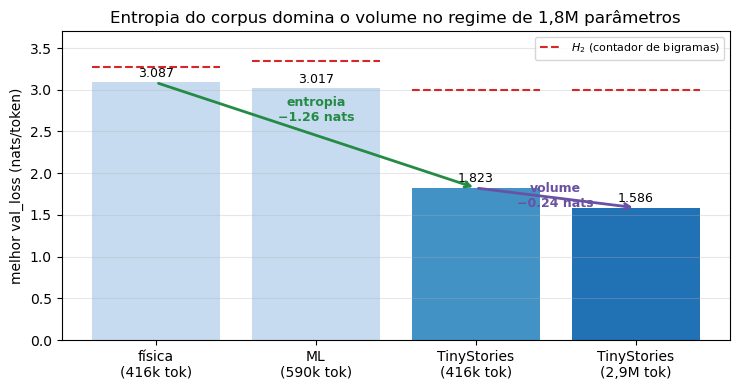

In [13]:
# Reaproveita `rows` da célula anterior.
labels = ["física\n(416k tok)", "ML\n(590k tok)",
          "TinyStories\n(416k tok)", "TinyStories\n(2,9M tok)"]
vals   = [r[3] for r in rows]
h2s    = [r[2] for r in rows]
# claro = volume de ~416k (par controlado por volume); escuro = corpus completo
colors = ["#c6dbef", "#c6dbef", "#4292c6", "#2171b5"]

fig, ax = plt.subplots(figsize=(7.5, 4))
bars = ax.bar(labels, vals, color=colors)
for b, v, h2 in zip(bars, vals, h2s):
    x0, x1 = b.get_x(), b.get_x() + b.get_width()
    ax.hlines(h2, x0, x1, ls="--", color="#d62728", lw=1.5)
    ax.text(b.get_x() + b.get_width()/2, v + 0.03, f"{v:.3f}",
            ha="center", va="bottom", fontsize=9)

# anota os dois efeitos isolados
ax.annotate("", xy=(2, vals[2]), xytext=(0, vals[0]),
            arrowprops=dict(arrowstyle="->", color="#238b45", lw=2))
ax.text(1.0, 2.62, f"entropia\n−{vals[0]-vals[2]:.2f} nats", color="#238b45",
        fontsize=9, ha="center", fontweight="bold")
ax.annotate("", xy=(3, vals[3]), xytext=(2, vals[2]),
            arrowprops=dict(arrowstyle="->", color="#6a51a3", lw=2))
ax.text(2.5, 1.60, f"volume\n−{vals[2]-vals[3]:.2f} nats", color="#6a51a3",
        fontsize=9, ha="center", fontweight="bold")

ax.set_ylim(0, 3.7); ax.set_ylabel("melhor val_loss (nats/token)")
ax.set_title("Entropia do corpus domina o volume no regime de 1,8M parâmetros")
ax.legend(handles=[plt.Line2D([0], [0], ls="--", color="#d62728")],
          labels=["$H_2$ (contador de bigramas)"], fontsize=8, loc="upper right")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

In [14]:
# Estima params de um modelo estilo LLaMA (RMSNorm/SwiGLU/RoPE, weight tying) por preset,
# e o T/N contra um corpus hipotético — para enxergar a distância do ótimo Chinchilla (~20).
def hidden_dim(d, multiple_of=64):
    h = int(8 * d / 3)
    return ((h + multiple_of - 1) // multiple_of) * multiple_of

def est_params(d, L, vocab=8192):
    emb   = vocab * d                     # embedding (compartilhada com lm_head via weight tying)
    attn  = L * (4 * d * d)               # q,k,v,out projections (sem bias)
    h     = hidden_dim(d)
    mlp   = L * (3 * d * h)               # gate, up, down (SwiGLU)
    norms = L * 2 * d + d                 # RMSNorm (gammas) + norm final
    return emb + attn + mlp + norms

PRESETS = {"small": (128, 6), "base": (256, 8), "medium": (512, 12),
           "large": (768, 12), "xl": (1024, 16)}
CORPUS_TOKENS = 25_300_000                # corpus v3 do projeto

print(f"{'preset':7s} {'d':>5} {'L':>3} {'N (M)':>8} {'T/N':>7} {'regime':>18}")
for name, (d, L) in PRESETS.items():
    N = est_params(d, L)
    tn = CORPUS_TOKENS / N
    regime = "compute constrained" if tn < 20 else "data constrained"
    print(f"{name:7s} {d:>5} {L:>3} {N/1e6:>8.1f} {tn:>7.2f} {regime:>19}")
print(f"\notimo Chinchilla: T/N ~ 20  |  para o 'medium' atingir isso, precisaria de ~{est_params(512,12)*20/1e9:.1f}B tokens")

preset      d   L    N (M)     T/N             regime
small     128   6      2.3   10.87 compute constrained
base      256   8      8.5    2.97 compute constrained
medium    512  12     42.7    0.59 compute constrained
large     768  12     91.2    0.28 compute constrained
xl       1024  16    210.8    0.12 compute constrained

otimo Chinchilla: T/N ~ 20  |  para o 'medium' atingir isso, precisaria de ~0.9B tokens


Em escala log, a distância do ótimo salta aos olhos: a linha tracejada é
$T/N = 20$ (Chinchilla); **todas** as barras ficam ordens de magnitude abaixo — o
projeto inteiro é *compute constrained*. Quanto maior o modelo, mais fundo o buraco
(menos tokens por parâmetro), reforçando: no regime atual, mais dados > mais params.

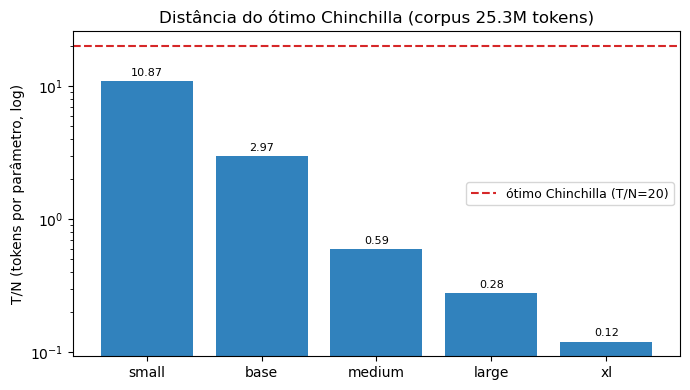

In [15]:
# Recalcula T/N por preset (reaproveitando est_params/PRESETS/CORPUS_TOKENS).
names = list(PRESETS)
tns   = [CORPUS_TOKENS / est_params(*PRESETS[n]) for n in names]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(names, tns, color="#3182bd")
ax.axhline(20, ls="--", color="#d62728", lw=1.5, label="ótimo Chinchilla (T/N=20)")
ax.set_yscale("log")
for b, t in zip(bars, tns):
    ax.text(b.get_x()+b.get_width()/2, t*1.1, f"{t:.2f}", ha="center", fontsize=8)
ax.set_ylabel("T/N (tokens por parâmetro, log)")
ax.set_title(f"Distância do ótimo Chinchilla (corpus {CORPUS_TOKENS/1e6:.1f}M tokens)")
ax.legend(fontsize=9); plt.tight_layout(); plt.show()

Todos os presets ficam muito abaixo de `T/N ≈ 20` com este corpus — são
*compute constrained*. A conclusão prática (e o que ordena o roadmap na
`ARCHITECTURE.md`): **a próxima alavanca é dado, não parâmetro**. Escalar o modelo
antes de escalar o corpus é desperdício de compute.

## Resumo (o que fecha a série)

| Peça | O que faz | Stub que alimenta |
|---|---|---|
| `bits_per_char` | cross-entropy → BPC (portável entre tokenizers) | `training/evaluate.py` |
| `evaluate` | val_loss (nats/token) + next-token accuracy | `training/evaluate.py` |
| `sample_next` | temperatura, top-k, top-p, repetition penalty | `inference/generate.py` |
| `generate` | loop autoregressivo (KV-cache no nb 04) | `inference/generate.py` |
| diagnóstico `T/N` | regime Chinchilla; dado vs capacidade | roadmap (`ARCHITECTURE.md`) |

**Caminho de evolução:** o projeto Chinchilla (Hoffmann et al., 2022) para a lei de
escala; e, como ferramenta, `lm-evaluation-harness` (EleutherAI) para trocar
"loss em held-out" por benchmarks estruturados (HellaSwag, ARC, MMLU) — o próximo
passo de avaliação do roadmap.

**Fim da série (00 → 07).** Agora o exercício: preencha os stubs em `src/tucanoce/`
a partir do que cada notebook derivou. Ao terminar, `src/` vira um LM treinável —
escrito por você.